# Day 2.5 — Tiny synthetic orientation CNN

Bridge fixed manual kernels and the full CIFAR-10 CNN by training a very small CNN on synthetic grayscale orientation patterns.

This notebook should stay intentionally smaller than the CIFAR-10 tutorial: one input channel, two classes, two small convolution layers, and one final linear classifier.


## Official / supplemental anchors

- PyTorch `torch.nn.Conv2d` docs: https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- PyTorch `torch.nn.MaxPool2d` docs: https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html
- PyTorch `torch.nn.CrossEntropyLoss` docs: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- Supplemental inspiration: Neuromatch orientation/grating convolution material. Use it as a bridge idea, not as a replacement for this repo's learning path.


## Planned learning path

1. Generate a tiny local synthetic dataset of `32 x 32` grayscale orientation images.
2. Show a labeled sample grid before training.
3. Wrap tensors in `TensorDataset` and `DataLoader`.
4. Define a tiny two-convolution CNN with one final classifier layer.
5. Trace shapes through the network step by step.
6. Train briefly and treat accuracy as a sanity check.
7. Save a sample grid, loss curve, learned filter grid, and at least one activation grid under `outputs/day02b_tiny_orientation_cnn/`.


In [70]:
from pathlib import Path

current_dir: Path = Path.cwd()
PROJECT_ROOT: Path = next(
    (candidate for candidate in (current_dir, *current_dir.parents) if (candidate / "pyproject.toml").exists()),
    current_dir,
)
OUTPUT_DIR: Path = PROJECT_ROOT / "outputs" / "day02b_tiny_orientation_cnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: C:\Users\giloz\dev\cnn-feature-map-lab
Output directory: C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day02b_tiny_orientation_cnn


## Generate synthetic tilted-line images

Generate two-class grayscale images with short tilted line segments. Keep the variation mild enough that the examples remain visually inspectable while still being less trivial than centered vertical and horizontal bars.


In [71]:
import math

import torch

torch.manual_seed(7)

num_examples: int = 400
image_size: int = 32

images = torch.zeros(num_examples, 1, image_size, image_size)
labels = torch.zeros(num_examples, dtype=torch.long)

yy, xx = torch.meshgrid(
    torch.arange(image_size),
    torch.arange(image_size),
    indexing="ij",
)

for i in range(num_examples):
    label: int = i % 2
    labels[i] = label

    # Class 0 uses a negative angle; class 1 uses a positive angle.
    base_angle_degrees: float = -35.0 if label == 0 else 35.0
    angle_degrees: float = base_angle_degrees + float(torch.empty(1).uniform_(-8.0, 8.0).item())
    angle_radians: float = math.radians(angle_degrees)

    center_x: float = image_size / 2 + float(torch.empty(1).uniform_(-5.0, 5.0).item())
    center_y: float = image_size / 2 + float(torch.empty(1).uniform_(-5.0, 5.0).item())

    length: float = float(torch.empty(1).uniform_(14.0, 24.0).item())
    thickness: float = float(torch.empty(1).uniform_(1.4, 2.8).item())

    dx = xx - center_x
    dy = yy - center_y

    # Rotate coordinates so one axis runs along the line and the other crosses it.
    along = dx * math.cos(angle_radians) + dy * math.sin(angle_radians)
    across = -dx * math.sin(angle_radians) + dy * math.cos(angle_radians)

    line_mask = (along.abs() <= length / 2) & (across.abs() <= thickness)

    images[i, 0, line_mask] = 1.0

noise = 0.12 * torch.randn_like(images)
images = (images + noise).clamp(min=0.0, max=1.0)

print("images:", images.shape)
print("labels:", labels.shape)
print("first labels:", labels[:8])
print("pixel range:", float(images.min()), "to", float(images.max()))

images: torch.Size([400, 1, 32, 32])
labels: torch.Size([400])
first labels: tensor([0, 1, 0, 1, 0, 1, 0, 1])
pixel range: 0.0 to 1.0


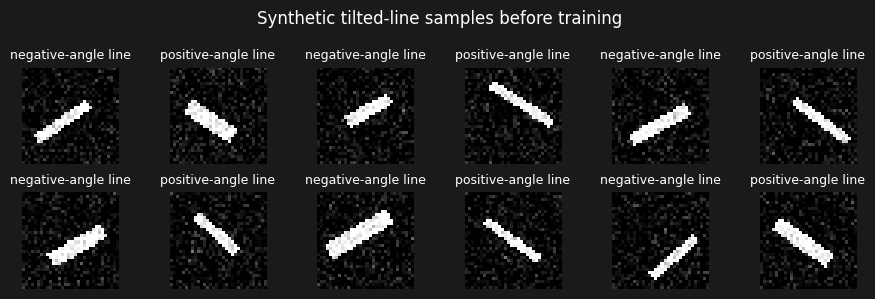

Saved sample grid to: C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day02b_tiny_orientation_cnn\synthetic_sample_grid.png


In [72]:
import matplotlib.pyplot as plt

class_names: list[str] = ["negative-angle line", "positive-angle line"]

fig, axes = plt.subplots(2, 6, figsize=(9, 3))

for ax, image, label in zip(axes.flat, images[:12], labels[:12], strict=False):
    ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(class_names[int(label)], fontsize=9)
    ax.axis("off")

fig.suptitle("Synthetic tilted-line samples before training")
fig.tight_layout()

sample_grid_path = OUTPUT_DIR / "synthetic_sample_grid.png"
fig.savefig(sample_grid_path, dpi=150)
plt.show()

print(f"Saved sample grid to: {sample_grid_path}")

## DataLoader placeholder

Wrap the generated tensors in `TensorDataset` and `DataLoader` so this bridge introduces the same batch-feeding pattern used in the CIFAR-10 notebook without external data.


In [73]:
from torch.utils.data import DataLoader, TensorDataset

batch_size: int = 32

dataset = TensorDataset(images, labels)

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
)

batch_images, batch_labels = next(iter(train_loader))

print("batch images:", batch_images.shape)
print("batch labels:", batch_labels.shape)
print("batch labels preview:", batch_labels[:10])

batch images: torch.Size([32, 1, 32, 32])
batch labels: torch.Size([32])
batch labels preview: tensor([0, 0, 0, 1, 0, 1, 1, 1, 0, 0])


## Tiny CNN placeholder

Use a deliberately smaller architecture than the CIFAR-10 notebook: two convolution layers, pooling, flattening, and one final classifier. Use explicit keyword arguments in layer constructors.


In [74]:
import torch.nn as nn
import torch.nn.functional as F


class TinyOrientationCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=4,
            kernel_size=3,
            padding=1,
        )
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )
        self.conv2 = nn.Conv2d(
            in_channels=4,
            out_channels=8,
            kernel_size=3,
            padding=1,
        )
        # after applying the second max pooling (32, 8, 8, 8) and flattening it to (32, 8 * 8 * 8)
        self.classifier = nn.Linear(
            in_features=8 * 8 * 8,
            out_features=2,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


model = TinyOrientationCNN()
print(model)

TinyOrientationCNN(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (classifier): Linear(in_features=512, out_features=2, bias=True)
)


## Trace shapes through the tiny CNN

This section should mirror the step-by-step shape tracing style used in `notebooks/03_tiny_cifar10_cnn.ipynb`. Use separate markdown and code cells for each transformation. Each code cell should update `x` once and print `x.shape`.

Expected path:

```text
input:      [batch, 1, 32, 32]
conv1:      [batch, 4, 32, 32]
relu1:      [batch, 4, 32, 32]
pool1:      [batch, 4, 16, 16]
conv2:      [batch, 8, 16, 16]
relu2:      [batch, 8, 16, 16]
pool2:      [batch, 8, 8, 8]
flatten:    [batch, 512]
classifier: [batch, 2]
```


### Input batch

Start with one mini-batch from the synthetic `DataLoader`. The shape should be `[batch, 1, 32, 32]`: batch size, one grayscale channel, height, width.


In [75]:
model.eval()
x, trace_labels = next(iter(train_loader))
print("input:", x.shape)

input: torch.Size([32, 1, 32, 32])


### `conv1`: one grayscale channel → four feature maps

The first convolution should change the channel count from `1` to `4` while keeping height and width at `32 x 32` because `padding=1` with `kernel_size=3` preserves spatial size.


In [76]:
x = model.conv1(x)
print("after conv1:", x.shape)

after conv1: torch.Size([32, 4, 32, 32])


### `relu1`: value change only

ReLU should keep the same shape and only change values by zeroing negative responses.


In [77]:
x = F.relu(x)
print("after relu1:", x.shape)

after relu1: torch.Size([32, 4, 32, 32])


### `pool1`: halve height and width

The first max-pooling step should keep `4` channels and shrink spatial size from `32 x 32` to `16 x 16`.


In [78]:
x = model.pool(x)
print("after pool1:", x.shape)

after pool1: torch.Size([32, 4, 16, 16])


### `conv2`: four feature maps → eight feature maps

The second convolution should read the four first-layer feature maps and produce eight second-layer feature maps. Spatial size should stay `16 x 16`.


In [79]:
x = model.conv2(x)
print("after conv2:", x.shape)

after conv2: torch.Size([32, 8, 16, 16])


### `relu2`: value change only

Again, ReLU should keep the same shape and only change activation values.


In [80]:
x = F.relu(x)
print("after relu2:", x.shape)

after relu2: torch.Size([32, 8, 16, 16])


### `pool2`: shrink to `8 x 8` feature maps

The second max-pooling step should keep `8` channels and shrink spatial size from `16 x 16` to `8 x 8`.


In [81]:
x = model.pool(x)
print("after pool2:", x.shape)

after pool2: torch.Size([32, 8, 8, 8])


### `flatten`: feature maps → vector per image

Flatten should keep the batch dimension and turn `8 * 8 * 8` values into a 512-value vector per image.


In [82]:
x = torch.flatten(x, 1)
print("after flatten:", x.shape)

after flatten: torch.Size([32, 512])


### `classifier`: 512 values → two class scores

The final linear layer should produce two raw scores per image, one for each synthetic orientation class.


In [83]:
x = model.classifier(x)
print("after classifier:", x.shape)

after classifier: torch.Size([32, 2])


## Train the tiny CNN

Train briefly with `CrossEntropyLoss`. Accuracy is only a sanity check; the real goal is to create learned filters and activations that can be inspected.


In [84]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs: int = 10
history: list[dict[str, float]] = []

for epoch in range(num_epochs):
    model.train()
    running_loss: float = 0.0
    correct: int = 0
    seen: int = 0

    for batch_images, batch_labels in train_loader:
        optimizer.zero_grad()

        logits = model(batch_images)
        loss = loss_fn(logits, batch_labels)

        loss.backward()
        optimizer.step()

        batch_count: int = batch_images.shape[0]
        running_loss += float(loss.item()) * batch_count
        correct += int((logits.argmax(dim=1) == batch_labels).sum().item())
        seen += batch_count

    epoch_loss: float = running_loss / seen
    epoch_accuracy: float = correct / seen

    history.append(
        {
            "epoch": float(epoch + 1),
            "loss": epoch_loss,
            "accuracy": epoch_accuracy,
        }
    )

    print(f"epoch {epoch + 1:02d} | loss {epoch_loss:.4f} | accuracy {epoch_accuracy:.3f}")

epoch 01 | loss 0.4470 | accuracy 0.807
epoch 02 | loss 0.2047 | accuracy 0.915
epoch 03 | loss 0.0883 | accuracy 0.970
epoch 04 | loss 0.0375 | accuracy 0.998
epoch 05 | loss 0.0199 | accuracy 0.995
epoch 06 | loss 0.0089 | accuracy 0.998
epoch 07 | loss 0.0041 | accuracy 1.000
epoch 08 | loss 0.0019 | accuracy 1.000
epoch 09 | loss 0.0013 | accuracy 1.000
epoch 10 | loss 0.0009 | accuracy 1.000


## Save training artifacts and inspect learned feature maps

Save the training curve, the learned `conv1` filter grid, and activation grids from both convolution layers under `outputs/day02b_tiny_orientation_cnn/`.


### Save the training loss curve and history table

The loss curve records whether the short training run moved in the expected direction. The CSV keeps the same epoch-by-epoch numbers in a small file that is easy to inspect later.


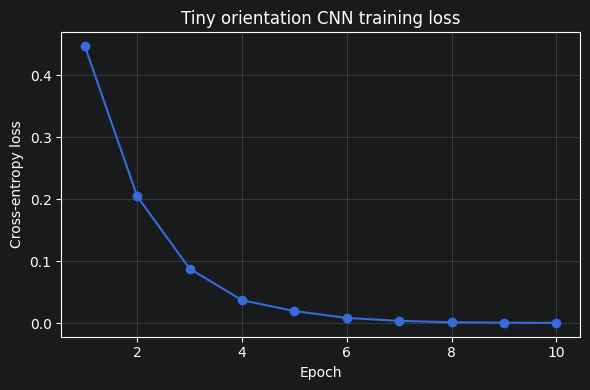

Saved loss curve to: C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day02b_tiny_orientation_cnn\training_loss_curve.png
Saved training history to: C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day02b_tiny_orientation_cnn\training_history.csv


In [85]:
loss_curve_path: Path = OUTPUT_DIR / "training_loss_curve.png"
history_table_path: Path = OUTPUT_DIR / "training_history.csv"

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    [row["epoch"] for row in history],
    [row["loss"] for row in history],
    marker="o",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Tiny tilted-line CNN training loss")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(loss_curve_path, dpi=150)
plt.show()

with history_table_path.open("w", encoding="utf-8") as table_file:
    table_file.write("epoch,loss,accuracy\n")
    for row in history:
        table_file.write(f"{int(row['epoch'])},{row['loss']:.6f},{row['accuracy']:.6f}\n")

print(f"Saved loss curve to: {loss_curve_path}")
print(f"Saved training history to: {history_table_path}")

### Inspect learned `conv1` filters and first-layer activations

The `conv1` filters are the first learned kernels. The `conv1` activation maps show where those kernels respond on one selected tilted-line image.


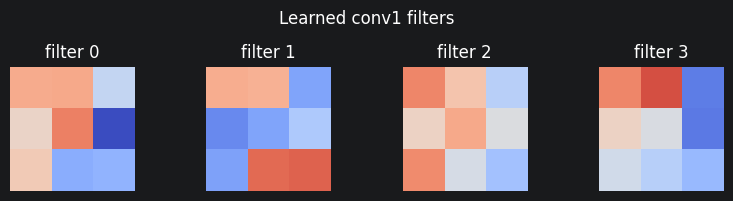

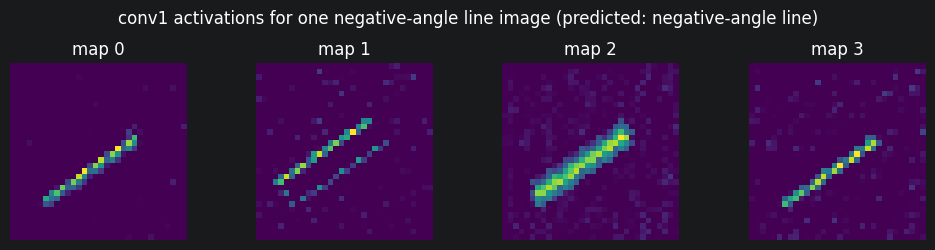

Saved learned filter grid to: C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day02b_tiny_orientation_cnn\learned_conv1_filter_grid.png
Saved activation grid to: C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day02b_tiny_orientation_cnn\conv1_activation_grid.png


In [86]:
model.eval()

conv1_filters = model.conv1.weight.detach().cpu()
filter_limit: float = float(conv1_filters.abs().max())

fig, axes = plt.subplots(1, conv1_filters.shape[0], figsize=(8, 2))

for filter_index, ax in enumerate(axes):
    ax.imshow(
        conv1_filters[filter_index, 0],
        cmap="coolwarm",
        vmin=-filter_limit,
        vmax=filter_limit,
    )
    ax.set_title(f"filter {filter_index}")
    ax.axis("off")

fig.suptitle("Learned conv1 filters")
fig.tight_layout()

filter_grid_path: Path = OUTPUT_DIR / "learned_conv1_filter_grid.png"
fig.savefig(filter_grid_path, dpi=150)
plt.show()

sample_index: int = 0
sample_image = images[sample_index : sample_index + 1]
sample_label: int = int(labels[sample_index])

with torch.no_grad():
    conv1_activations = F.relu(model.conv1(sample_image)).detach().cpu()
    predicted_label: int = int(model(sample_image).argmax(dim=1).item())

fig, axes = plt.subplots(1, conv1_activations.shape[1], figsize=(10, 2.5))

for activation_index, ax in enumerate(axes):
    ax.imshow(conv1_activations[0, activation_index], cmap="viridis")
    ax.set_title(f"map {activation_index}")
    ax.axis("off")

fig.suptitle(f"conv1 activations for one {class_names[sample_label]} image (predicted: {class_names[predicted_label]})")
fig.tight_layout()

activation_grid_path: Path = OUTPUT_DIR / "conv1_activation_grid.png"
fig.savefig(activation_grid_path, dpi=150)
plt.show()

print(f"Saved learned filter grid to: {filter_grid_path}")
print(f"Saved activation grid to: {activation_grid_path}")

### Inspect second-layer `conv2` activations

The second convolution sees the first-layer feature maps after ReLU and pooling. These `conv2` activation maps are less like raw pixels and more like combinations of earlier line/edge responses.


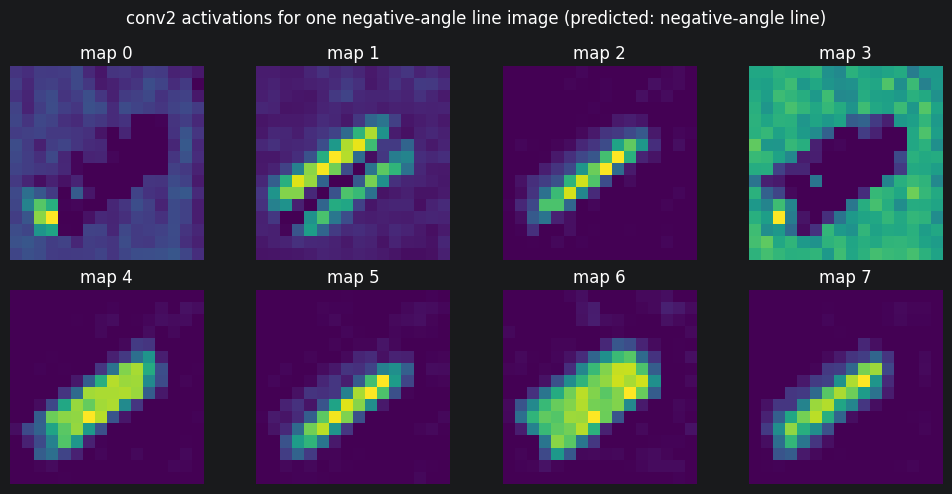

conv2 activations: torch.Size([1, 8, 16, 16])
Saved conv2 activation grid to: C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day02b_tiny_orientation_cnn\conv2_activation_grid.png


In [87]:
with torch.no_grad():
    conv1_response = F.relu(model.conv1(sample_image))
    pooled_conv1_response = model.pool(conv1_response)
    conv2_activations = F.relu(model.conv2(pooled_conv1_response)).detach().cpu()
    predicted_label: int = int(model(sample_image).argmax(dim=1).item())

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for activation_index, ax in enumerate(axes.flat):
    ax.imshow(conv2_activations[0, activation_index], cmap="viridis")
    ax.set_title(f"map {activation_index}")
    ax.axis("off")

fig.suptitle(f"conv2 activations for one {class_names[sample_label]} image (predicted: {class_names[predicted_label]})")
fig.tight_layout()

conv2_activation_grid_path: Path = OUTPUT_DIR / "conv2_activation_grid.png"
fig.savefig(conv2_activation_grid_path, dpi=150)
plt.show()

print("conv2 activations:", conv2_activations.shape)
print(f"Saved conv2 activation grid to: {conv2_activation_grid_path}")

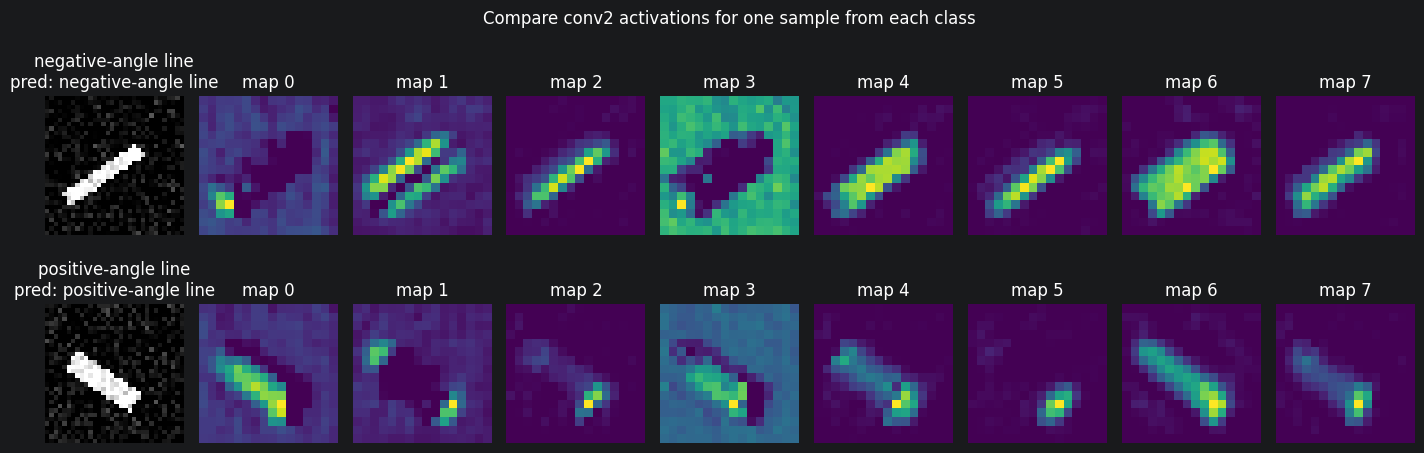

In [88]:
class_0_index: int = int((labels == 0).nonzero()[0].item())
class_1_index: int = int((labels == 1).nonzero()[0].item())

comparison_images = images[[class_0_index, class_1_index]]
comparison_labels = labels[[class_0_index, class_1_index]]

with torch.no_grad():
    conv1_response = F.relu(model.conv1(comparison_images))
    pooled_conv1_response = model.pool(conv1_response)
    conv2_response = F.relu(model.conv2(pooled_conv1_response)).detach().cpu()
    predictions = model(comparison_images).argmax(dim=1)

fig, axes = plt.subplots(2, conv2_response.shape[1] + 1, figsize=(14, 5))

for row_index in range(2):
    axes[row_index, 0].imshow(comparison_images[row_index, 0], cmap="gray", vmin=0, vmax=1)
    axes[row_index, 0].set_title(
        f"{class_names[int(comparison_labels[row_index])]}\npred: {class_names[int(predictions[row_index])]}"
    )
    axes[row_index, 0].axis("off")

    for map_index in range(conv2_response.shape[1]):
        axes[row_index, map_index + 1].imshow(conv2_response[row_index, map_index], cmap="viridis")
        axes[row_index, map_index + 1].set_title(f"map {map_index}")
        axes[row_index, map_index + 1].axis("off")

fig.suptitle("Compare conv2 activations for one sample from each class")
fig.tight_layout()
plt.show()

### Reading the same feature map on different inputs

A feature map is not a stored picture of one class, and it is not a picture of the learned weights themselves. It is the response produced when the same learned filter is applied to the current input image.

The learned filter weights stay fixed during inspection. The activation values change when the input image changes. That means the same `conv2` map can visually trace a `/`-leaning stroke for one sample and a `\`-leaning stroke for another sample if the learned filter responds to a more general local cue, such as diagonalness, a bright stroke edge, line interior, endpoint, or nearby dark-to-bright contrast.

This was an important correction to my mental model: the filter grid shows the detector's learned weights, while the activation grid shows where that detector fired for a specific image.

So when comparing activation maps, read them as evidence signals: where did this learned detector respond strongly on this specific image, and how does that response differ between the two classes? The goal is not to force one feature map to mean one class, but to notice what kinds of visual evidence the network can reuse.


## Reflection

Write 3-5 sentences answering:

- Which part felt like Day 2 fixed kernels?
- Which part starts to feel like Day 3 CNN training?
- What did the second convolution layer add conceptually?
- Why does this bridge make CIFAR-10 feel less abrupt?
